# Forecasting toy: the 2026-warmest-year equation model

Same shape as `toy_linear_flow`, but the real prediction constraints: five leaves
(`trend`, `enso`, `volcanic`, plus derived `anomaly`, `record`) pinned by elicited
means/tail bounds, tied together by the structural equation
`anomaly = trend + 0.075*enso - volcanic ~ N(0, 0.035)` and the threshold
`record = ind(anomaly > 1.60)`.

The question this toy makes visible: the flow satisfies the residual's first two
moments, but does it keep the residual **independent** of the right-hand side, or
does it anti-correlate in the tail and clip `P(anomaly > 1.60)` below the
independent max-entropy target?

In [2]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.models.variable import BinaryVariable, ContinuousVariable
from calibrated_response.models.natural_response import parse_natural_syntax as P
from calibrated_response.maxent_sampler.distribution_builder import DistributionBuilder

RECORD, NOISE, HAND_MC = 1.60, 0.035, 0.067   # threshold, eqn noise sd, hand Monte-Carlo ref

In [10]:

variables = [
    # BinaryVariable(name="record_2026", description="2026 warmest year on record"),
    # ContinuousVariable(name="time", description="", lower_bound=2000, upper_bound=2027, unit="year"), 
    ContinuousVariable(name="A", description="",
                           lower_bound=0, upper_bound=1, unit="C"),
    ContinuousVariable(name="B", description="",
                           lower_bound=0, upper_bound=1, unit="C"),
    ContinuousVariable(name="C", description="",
                           lower_bound=0, upper_bound=1, unit="C"),
    ContinuousVariable(name="anomaly", description="",
                       lower_bound=0, upper_bound=1, unit="C"),
]
estimates = [P(e) for e in [
    "E[A] = 0.5", "E[B] = 0.5", "E[C] = 0.5",
    "P(anomaly > 0.5 | A < 0.5) = 0.01",
    "P(anomaly > 0.5 | B < 0.5) = 0.01",
    "P(anomaly > 0.5 | C < 0.5) = 0.01",
]]

b = DistributionBuilder(variables, estimates, n_layers=8, hidden=64)
b.build(target_variable="anomaly", steps=1000, lr=2e-3, n_samples=2000, seed=0,
        entropy_reg=1e2)
print("done — joint entropy (nats):", round(b.entropy(), 3))

done — joint entropy (nats): -0.605


In [11]:
d = b.sample_dict(200000, seed=1)
A, B, C, anomaly = d["A"], d["B"], d["C"], d["anomaly"]
prob_anomaly = np.mean(anomaly > 0.5)
prob_anomaly_given_A = np.mean(anomaly[A > 0.5] > 0.5)
prob_anomaly_given_B = np.mean(anomaly[B > 0.5] > 0.5)
prob_anomaly_given_C = np.mean(anomaly[C > 0.5] > 0.5)
print(f"P(anomaly > 0.5) = {prob_anomaly:.3f}")
print(f"P(anomaly > 0.5 | A > 0.5) = {prob_anomaly_given_A:.3f}")
print(f"P(anomaly > 0.5 | B > 0.5) = {prob_anomaly_given_B:.3f}")
print(f"P(anomaly > 0.5 | C > 0.5) = {prob_anomaly_given_C:.3f}")
prob_anomaly_given_all = np.mean(anomaly[(A > 0.5) & (B > 0.5) & (C > 0.5)] > 0.5)
print(f"P(anomaly > 0.5 | A > 0.5, B > 0.5, C > 0.5) = {prob_anomaly_given_all:.3f}")


P(anomaly > 0.5) = 0.087
P(anomaly > 0.5 | A > 0.5) = 0.156
P(anomaly > 0.5 | B > 0.5) = 0.148
P(anomaly > 0.5 | C > 0.5) = 0.155
P(anomaly > 0.5 | A > 0.5, B > 0.5, C > 0.5) = 0.407


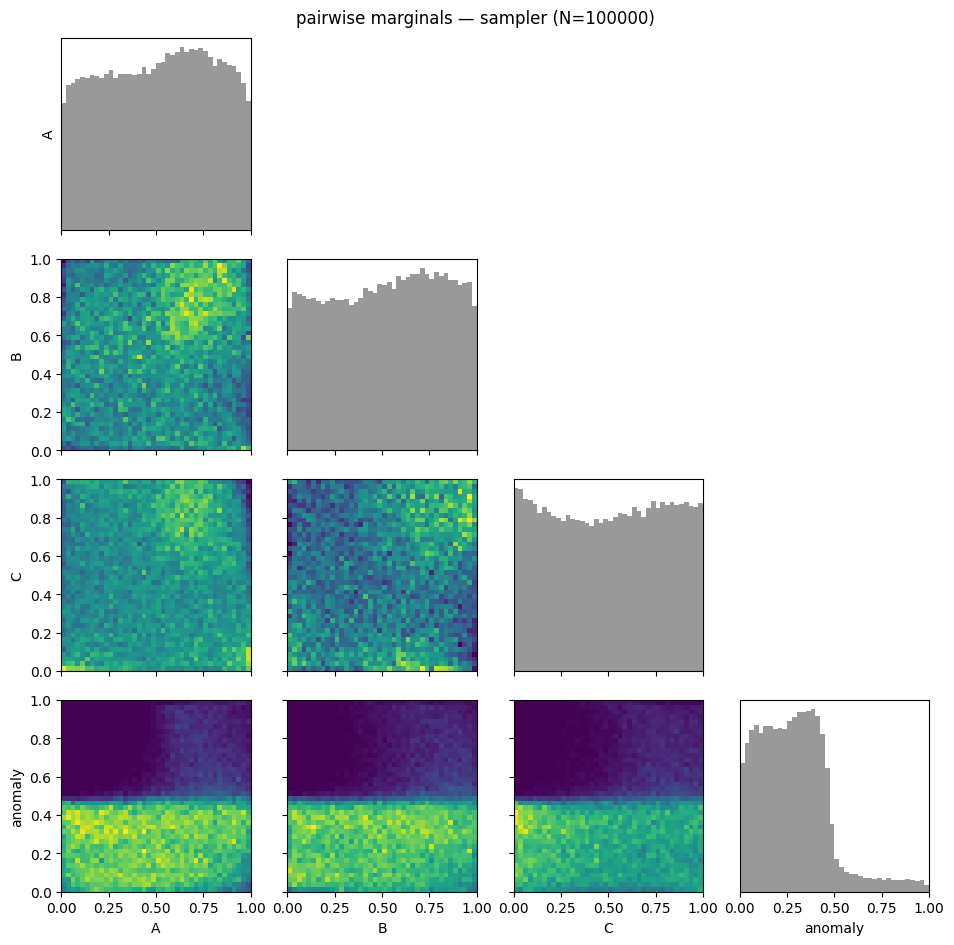

In [12]:
from calibrated_response.maxent_sampler.plotting import plot_pairwise
import matplotlib.pyplot as plt

fig, axes = plot_pairwise(b.model, b.params, n_samples=100_000)
plt.show()

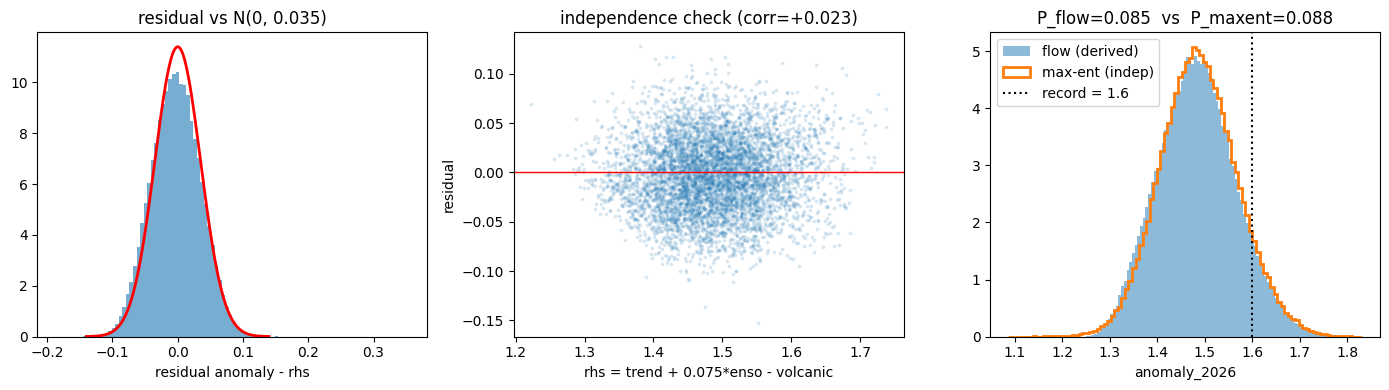

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# 1. residual marginal vs N(0, 0.035)
ax[0].hist(r, bins=100, density=True, alpha=0.6)
rr = np.linspace(-4 * NOISE, 4 * NOISE, 200)
ax[0].plot(rr, np.exp(-rr**2 / (2 * NOISE**2)) / (NOISE * np.sqrt(2 * np.pi)), "r-", lw=2)
ax[0].set(xlabel="residual anomaly - rhs", title=f"residual vs N(0, {NOISE})")

# 2. does the residual stay independent of the rhs? (clipping shows as a downward tilt)
ax[1].scatter(rhs[:6000], r[:6000], s=3, alpha=0.12)
ax[1].axhline(0, color="r", lw=1)
ax[1].set(xlabel="rhs = trend + 0.075*enso - volcanic", ylabel="residual",
          title=f"independence check (corr={np.corrcoef(rhs, r)[0,1]:+.3f})")

# 3. anomaly marginal: derived flow tail vs reconvolved-independent max-ent tail
ax[2].hist(an, bins=100, density=True, alpha=0.5, label="flow (derived)")
ax[2].hist(recon, bins=100, density=True, histtype="step", lw=2, label="max-ent (indep)")
ax[2].axvline(RECORD, color="k", ls=":", label=f"record = {RECORD}")
ax[2].set(xlabel="anomaly_2026", title="P_flow=%.3f  vs  P_maxent=%.3f" %
          (np.mean(an > RECORD), np.mean(recon > RECORD)))
ax[2].legend()

plt.tight_layout()